#
AI Pipeline using Pytorch
---

###
Introduction

---
This is an AI pipeline processing the MNIST Dataset.This dataset allows for demonstrating fundamentals of neural networks and clear example of how a neural network really works. It will go through stages of preparing, training, and evaluation and testing finally. The results and the variations in the hyperparameters value will allow the exhibition of the nature of a Multi-Layer Perceptron Neural Network. 
I will also compare my implementation to similar solutions from referenced sources, noting limitations and advantages of my proposed solution.

Learning Objectives 

You will understand the MNIST dataset

You will learn what machine learning is

You will learn how machine learning can be implemented to predict results in the future. 

You will understand hyperparameters in neural netowrks and how they 

##
Creating the Neural Network Pipeline
---

---
The first step of this is will be importing the relevant libraries and installing the relevant packages. 

In [2]:
!pip install torch torchvision matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\jevan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

These will install the pytorch and the relevant Pytorch libraries which are going to be used to create this neural network pipeline. 

The next step in this process is to establish the hyperparameters. 

A neural network is used to learn from data, and then is used to make predictions. You train it on inputs, and then it will be able to perform and predict that task well in the future. 

This neural network has many different configurations, configurations which you can change so that it performs most appropriately for your task. 

The configurations - known as Hyperparameters - are shown and coded below. 

In [4]:
config = {
    "batch_size": 64,
    "epochs": 5,
    "learning_rate": 0.001,
    "optimizer": "adam",
    "hidden_size": 128
}

We will be using the batch_size, epochs, learning_rate, optmizer, and hidden_size as hyperparameters. 

Batch size - While the neural netowrk is training, it is processing tens of thousands of images to train on. However, it only trains on 64 (batch size) images at a time. The neural network will predict 64 images, and then the loss will be propagated throughout the network , updating the weights and the bias, improving the neural network so that it becomes optimised to predict the images. Over time, the neural network should become more 'accurate' which is a statistic which will be shown visually later on. 

Epochs - An epoch is a full pass through all of the data. The neural network trains on the data multiple times (in this case '5'), becoming more optimal each time, however this must be chosen carefully due to the error of 'overoptimisation'.

Learning_rate - This is how significantly the weights and bias are adjusted during loss propagation (how harshly to correct).

Optimiser - This is the formula used for loss propagation, this could be 'adam' or 'sgd', and in this case we will be using adam.

hidden_size - This is the number of neurons / perceptrons in the hidden layer. This controls how complex the relationships are between inputs and outputs, increasing with the hidden layer size. 



Now, we will load the MNIST Dataset 

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False)

Transform - This is the preprocessing formula which will be used on each image.

train_dataset - this actually applying that preprocessing to each of the images. 

the rest is used to load the MNIST, and ensures that the images are shuffled each epoch. 

Now that we have the dataset imported, we are now going to write the model, the neural network model creation which is going to be used for training and predictions. 

In [6]:
class SimpleNN(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

This defines the neural netowork. It is flattened, mapping inputs to the hidden layer, and mapping the hidden layer perceptrons to output neurons. 
RELU is an activation function, this determines the output of a node, considering the weighted inputs and the bias. Another activation function is 'sigmoid' however this will not be used in this version. 

In order to prepare for training, the model, loss, and optimiser are created here. This facilitates improvement during the backpropagation phase of training.~

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleNN(config["hidden_size"]).to(device)
criterion = nn.CrossEntropyLoss()

if config["optimizer"].lower() == "adam":
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
elif config["optimizer"].lower() == "sgd":
    optimizer = optim.SGD(model.parameters(), lr=config["learning_rate"], momentum=0.9)
else:
    raise ValueError("Optimizer must be 'adam' or 'sgd'")

We will now create the main training function. This is what actually runs the training that has been prepared in previous stages. 

In [9]:
train_losses = []

for epoch in range(config["epochs"]):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{config['epochs']} - Loss: {avg_loss:.4f}")

Epoch 1/5 - Loss: 0.3960
Epoch 2/5 - Loss: 0.1992
Epoch 3/5 - Loss: 0.1457
Epoch 4/5 - Loss: 0.1181
Epoch 5/5 - Loss: 0.0994


This configures the training, for a certain amount of epochs, to loop through each image, to get the predictions through 'outputs' , and then compute the loss and 'learning' with the optimisers and loss as explained above. 



This now completes the pipeline for the training of the neural network, This is the basic skeleton of the training of a neural network for a dataset, however, there are more experiments whichi we need to consider to fully understand the neural netowrk. 

In the above output, after each epoch you can see the loss. It is performing as it should be as the loss is decreasing after each epoch ( from 0.39 to 0.09) - each training cycle - as the model is becoming better reading the numbers, as the MNIST  is a set of handwritten numbers.

A visual representation of this can be shown by utilising the python library matplotlib.

In [12]:
import matplotlib.pyplot as plt

import matplotlib and allow reference plt

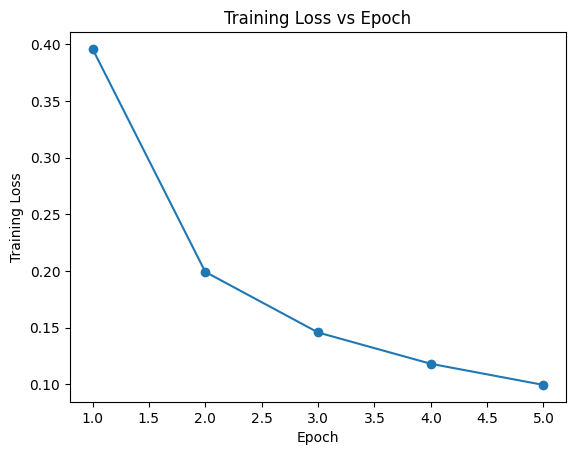

In [13]:
plt.plot(range(1, config["epochs"] + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.show()

We now have the visual displayed through matplotlib plotting training loss for each opoch which is decreasing at a decreasing rate, as the neural network converges to optimailty.

However we will need more intricate analysis and evaluation which I will incorporate right now.

##
Extending the Evaluation
---
---

I will now include an improved training procedure. This will allow more metrics to be tracked throughout training through the epochs such as accuracy, loss.

In [15]:
train_losses = []
train_accuracies = []
test_accuracies = []

model = SimpleNN(config["hidden_size"]).to(device)

if config["optimizer"] == "adam":
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
elif config["optimizer"] == "sgd":
    optimizer = optim.SGD(model.parameters(), lr=config["learning_rate"])

criterion = nn.CrossEntropyLoss()

for epoch in range(config["epochs"]):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    train_losses.append(avg_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{config['epochs']} - Loss: {avg_loss:.4f} - Train Acc: {train_accuracy:.2f}% - Test Acc: {test_accuracy:.2f}%")

Epoch 1/5 - Loss: 0.3760 - Train Acc: 89.11% - Test Acc: 93.75%
Epoch 2/5 - Loss: 0.1947 - Train Acc: 94.27% - Test Acc: 94.50%
Epoch 3/5 - Loss: 0.1391 - Train Acc: 95.79% - Test Acc: 95.81%
Epoch 4/5 - Loss: 0.1115 - Train Acc: 96.63% - Test Acc: 96.42%
Epoch 5/5 - Loss: 0.0925 - Train Acc: 97.16% - Test Acc: 96.86%


Instead of after the entire training, accuracy is tracked throughout using the total_train variable

I will now visualise this using matplotlib 

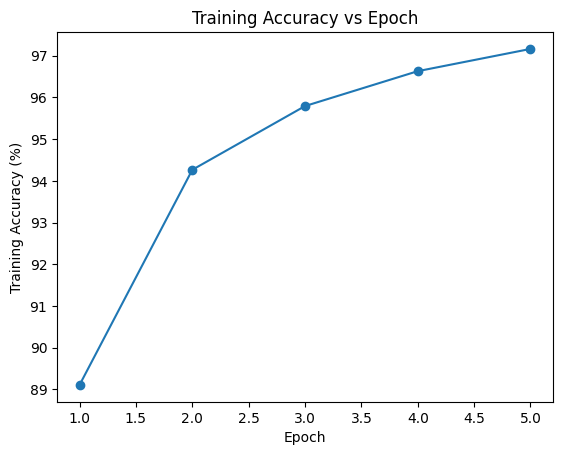

In [16]:
plt.plot(range(1, config["epochs"] + 1), train_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy vs Epoch")
plt.show()

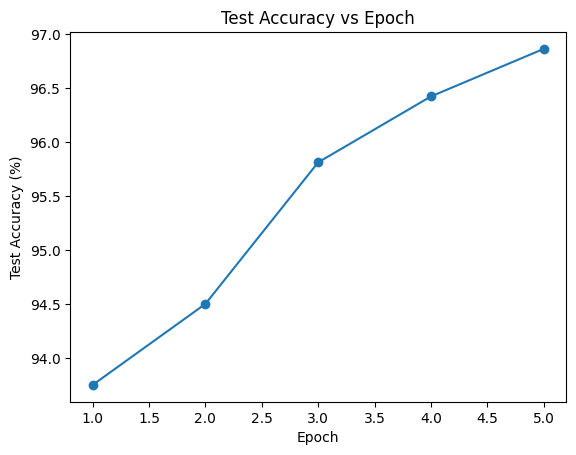

In [17]:
plt.plot(range(1, config["epochs"] + 1), test_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy vs Epoch")
plt.show()

This is convenient to see test and training accuracy match up. This means that we are not ending in a situation where we are 'over-fitting' where the increase in training accuracy does not reflect in the test, only fitting to the training data.

For these visualisations, you will need to access more libraries shown below, most importantly sklearn and pandas.

In [18]:
import copy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Subset, DataLoader

Create new functions to all the updated configurations for hyperparameters for the new visualisaitons

In [19]:
def build_model(config):

    return SimpleNN(config["hidden_size"]).to(device)

For the hidden layer size 

In [21]:
def build_optimizer(model, config):
    if config["optimizer"].lower() == "adam":
        return optim.Adam(model.parameters(), lr=config["learning_rate"])
    elif config["optimizer"].lower() == "sgd":
        return optim.SGD(model.parameters(), lr=config["learning_rate"])
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")

For the optimiser

In [22]:
def run_experiment(config, train_loader_used, test_loader_used):
    """
    Trains a fresh model from scratch and returns metrics for every epoch.
    """
    model = build_model(config)
    optimizer = build_optimizer(model, config)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(config["epochs"]):
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader_used:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_train_loss / len(train_loader_used)
        train_accuracy = 100 * correct_train / total_train

        model.eval()
        running_test_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for images, labels in test_loader_used:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        avg_test_loss = running_test_loss / len(test_loader_used)
        test_accuracy = 100 * correct_test / total_test

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        print(
            f"Epoch [{epoch+1}/{config['epochs']}] | "
            f"Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | Test Acc: {test_accuracy:.2f}%"
        )

    return {
        "config": copy.deepcopy(config),
        "model": model,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies
    }

Then creation of a new training fucnction which will consider all of these different configurations together


These will all be run through a a dictionary shown below

In [23]:
def run_experiment_group(experiment_dict, train_loader_used, test_loader_used):

    results = {}

    for name, config in experiment_dict.items():
        print("=" * 60)
        print(f"Running experiment: {name}")
        print(f"Config: {config}")
        print("=" * 60)

        results[name] = run_experiment(config, train_loader_used, test_loader_used)

    return results

Then we will plot these across all experiments

In [24]:
def plot_metric(results, metric_key, title, ylabel):

    plt.figure(figsize=(8, 5))

    for name, result in results.items():
        epochs = range(1, len(result[metric_key]) + 1)
        plt.plot(epochs, result[metric_key], marker='o', label=name)

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

Below will be a summary of the statistics which we have drawn

In [25]:
def summarise_results(results):
    """
    Creates a summary DataFrame using the final epoch values from each experiment.
    """
    rows = []

    for name, result in results.items():
        rows.append({
            "experiment": name,
            "hidden_size": result["config"]["hidden_size"],
            "epochs": result["config"]["epochs"],
            "learning_rate": result["config"]["learning_rate"],
            "optimizer": result["config"]["optimizer"],
            "final_train_loss": result["train_losses"][-1],
            "final_test_loss": result["test_losses"][-1],
            "final_train_accuracy": result["train_accuracies"][-1],
            "final_test_accuracy": result["test_accuracies"][-1]
        })

    return pd.DataFrame(rows).sort_values(by="final_test_accuracy", ascending=False).reset_index(drop=True)

Now we will prepare the specific learning rates which we will test the outcomes for.

In [27]:
learning_rate_experiments = {
    "lr_0.1": {
        "hidden_size": 128,
        "epochs": 5,
        "learning_rate": 0.1,
        "optimizer": "adam"
    },
    "lr_0.01": {
        "hidden_size": 128,
        "epochs": 5,
        "learning_rate": 0.01,
        "optimizer": "adam"
    },
    "lr_0.001": {
        "hidden_size": 128,
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "adam"
    }
}

learning_rate_results = run_experiment_group(learning_rate_experiments, train_loader, test_loader)

Running experiment: lr_0.1
Config: {'hidden_size': 128, 'epochs': 5, 'learning_rate': 0.1, 'optimizer': 'adam'}
Epoch [1/5] | Train Loss: 3.2812 | Test Loss: 2.3139 | Train Acc: 13.41% | Test Acc: 9.82%
Epoch [2/5] | Train Loss: 2.3094 | Test Loss: 2.3080 | Train Acc: 10.14% | Test Acc: 10.10%
Epoch [3/5] | Train Loss: 2.3097 | Test Loss: 2.3105 | Train Acc: 10.28% | Test Acc: 9.80%
Epoch [4/5] | Train Loss: 2.3094 | Test Loss: 2.3146 | Train Acc: 10.54% | Test Acc: 9.80%
Epoch [5/5] | Train Loss: 2.3097 | Test Loss: 2.3063 | Train Acc: 10.44% | Test Acc: 9.74%
Running experiment: lr_0.01
Config: {'hidden_size': 128, 'epochs': 5, 'learning_rate': 0.01, 'optimizer': 'adam'}
Epoch [1/5] | Train Loss: 0.3850 | Test Loss: 0.2516 | Train Acc: 88.60% | Test Acc: 92.60%
Epoch [2/5] | Train Loss: 0.2536 | Test Loss: 0.2340 | Train Acc: 92.53% | Test Acc: 93.30%
Epoch [3/5] | Train Loss: 0.2419 | Test Loss: 0.2384 | Train Acc: 93.09% | Test Acc: 92.84%
Epoch [4/5] | Train Loss: 0.2415 | Test Lo

What we can see here that we actually need to select the correct learning rate. If it is too quick ie with 0.1 or 0.01, we can see the test accuracy actually does not increase as the training accuracy increases. This is due to the neural netowrk learning to overfit and match the training data, so it isn't properly learning what makes a prediction right or wrong, but this can be avoided with the lower learning rate of 0.001 where training and test accuracy both increase as the model is learning at a rate where it is not overfitting and it is making more meaningful connections to what attributes to a correct prediction.

Prepare outputs for each of these 

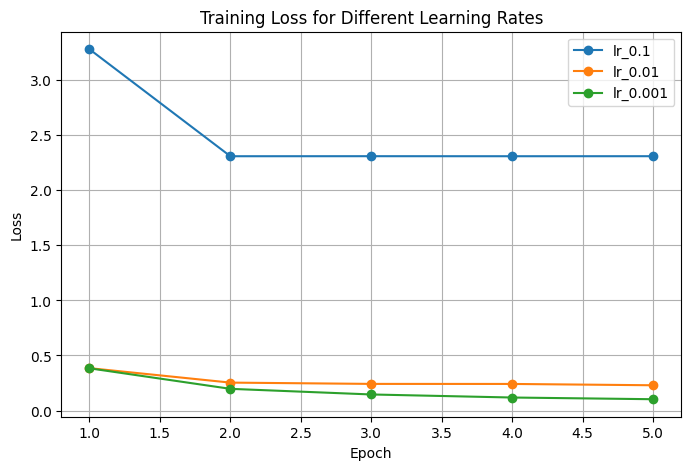

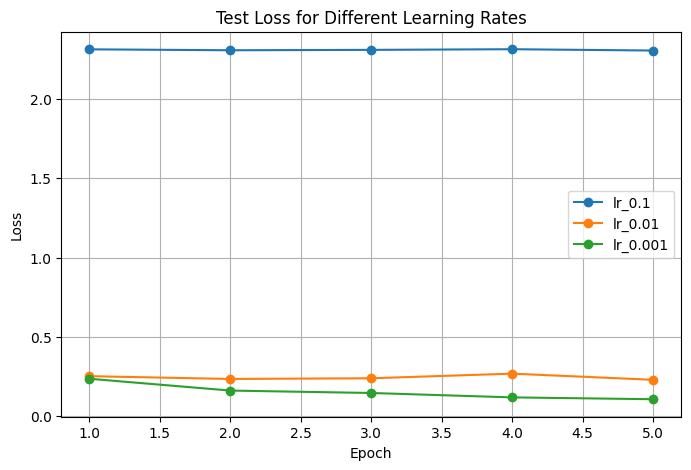

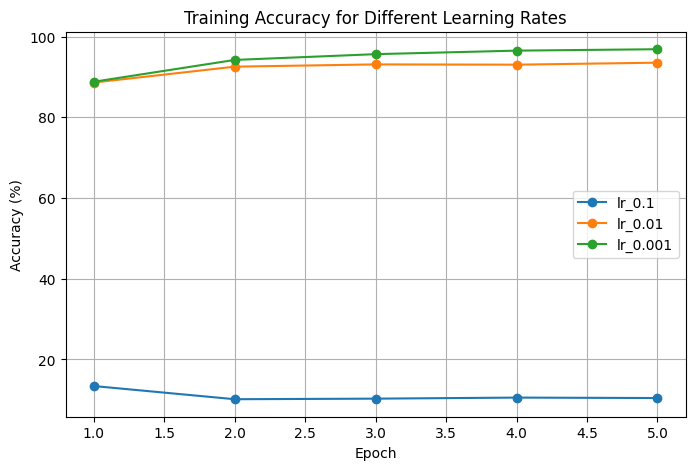

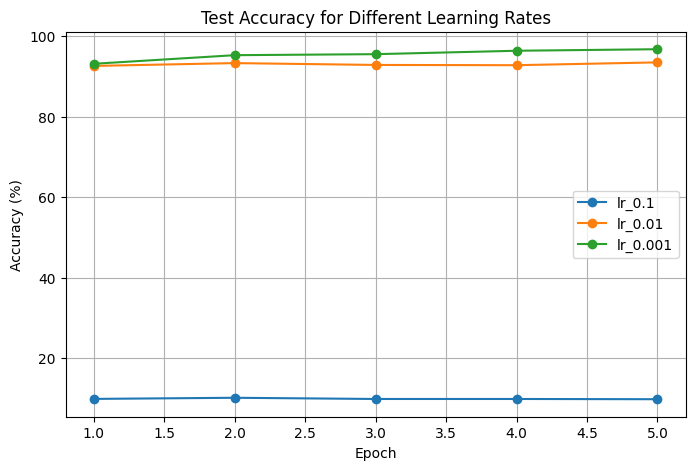

In [28]:
plot_metric(learning_rate_results, "train_losses", "Training Loss for Different Learning Rates", "Loss")
plot_metric(learning_rate_results, "test_losses", "Test Loss for Different Learning Rates", "Loss")
plot_metric(learning_rate_results, "train_accuracies", "Training Accuracy for Different Learning Rates", "Accuracy (%)")
plot_metric(learning_rate_results, "test_accuracies", "Test Accuracy for Different Learning Rates", "Accuracy (%)")

Output the results.

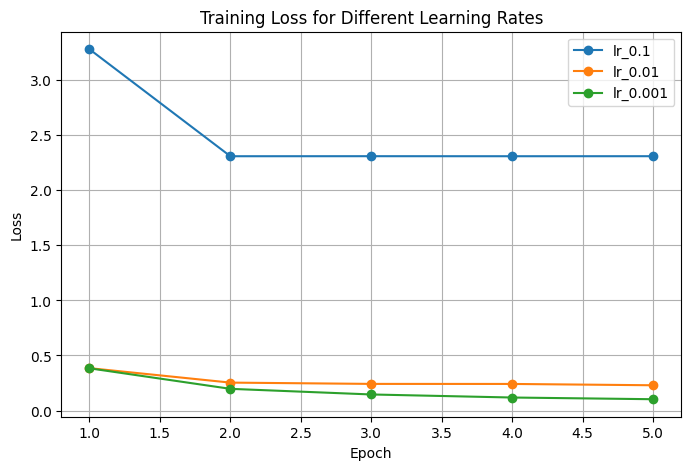

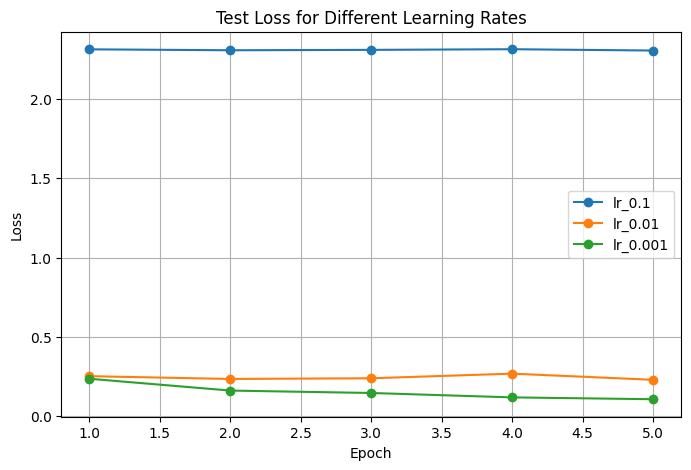

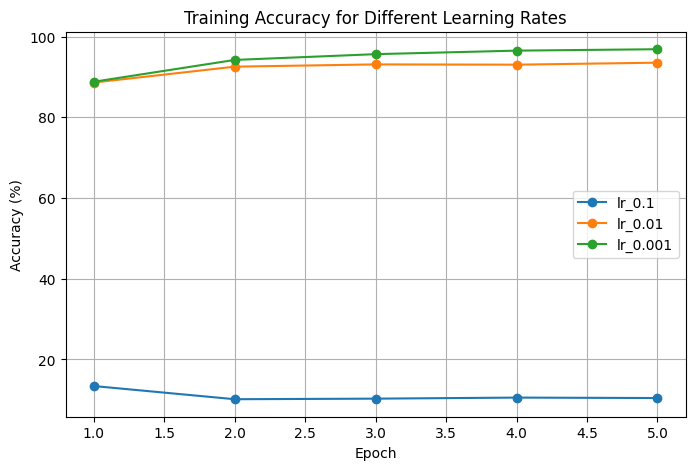

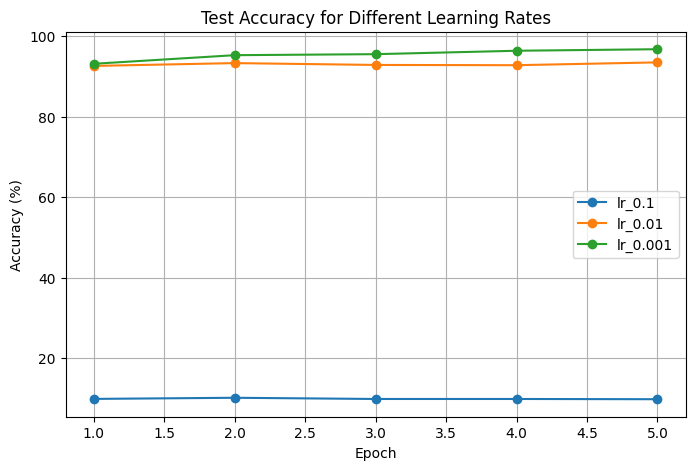

In [29]:
plot_metric(learning_rate_results, "train_losses", "Training Loss for Different Learning Rates", "Loss")
plot_metric(learning_rate_results, "test_losses", "Test Loss for Different Learning Rates", "Loss")
plot_metric(learning_rate_results, "train_accuracies", "Training Accuracy for Different Learning Rates", "Accuracy (%)")
plot_metric(learning_rate_results, "test_accuracies", "Test Accuracy for Different Learning Rates", "Accuracy (%)")

These graphs build on the conclusion I obtained through the other table of results I showed earlier.

Now we shall conduct a similar experiment for the hidden layer size, similar pipeline to the one which we have just done for learning rates. 

In [30]:
hidden_size_experiments = {
    "hidden_64": {
        "hidden_size": 64,
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "adam"
    },
    "hidden_128": {
        "hidden_size": 128,
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "adam"
    },
    "hidden_512": {
        "hidden_size": 512,
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "adam"
    }
}

hidden_size_results = run_experiment_group(hidden_size_experiments, train_loader, test_loader)

Running experiment: hidden_64
Config: {'hidden_size': 64, 'epochs': 5, 'learning_rate': 0.001, 'optimizer': 'adam'}
Epoch [1/5] | Train Loss: 0.4296 | Test Loss: 0.2728 | Train Acc: 87.79% | Test Acc: 92.07%
Epoch [2/5] | Train Loss: 0.2429 | Test Loss: 0.2176 | Train Acc: 92.84% | Test Acc: 93.62%
Epoch [3/5] | Train Loss: 0.1918 | Test Loss: 0.1631 | Train Acc: 94.41% | Test Acc: 95.03%
Epoch [4/5] | Train Loss: 0.1623 | Test Loss: 0.1514 | Train Acc: 95.20% | Test Acc: 95.50%
Epoch [5/5] | Train Loss: 0.1426 | Test Loss: 0.1494 | Train Acc: 95.74% | Test Acc: 95.53%
Running experiment: hidden_128
Config: {'hidden_size': 128, 'epochs': 5, 'learning_rate': 0.001, 'optimizer': 'adam'}
Epoch [1/5] | Train Loss: 0.3818 | Test Loss: 0.2251 | Train Acc: 88.97% | Test Acc: 93.32%
Epoch [2/5] | Train Loss: 0.2012 | Test Loss: 0.2120 | Train Acc: 94.14% | Test Acc: 93.66%
Epoch [3/5] | Train Loss: 0.1505 | Test Loss: 0.1356 | Train Acc: 95.52% | Test Acc: 95.88%
Epoch [4/5] | Train Loss: 0.12

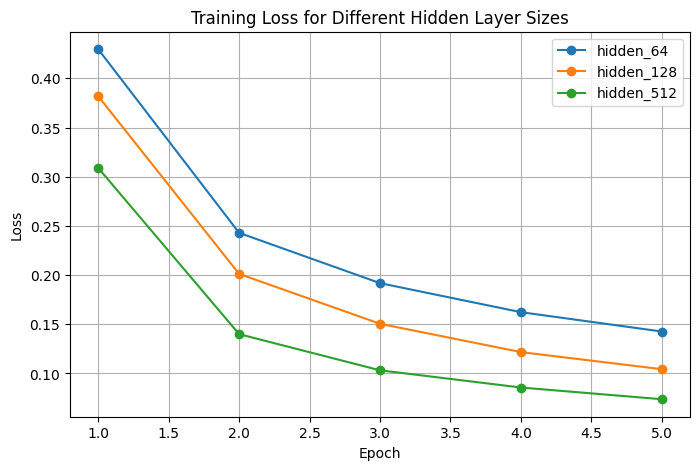

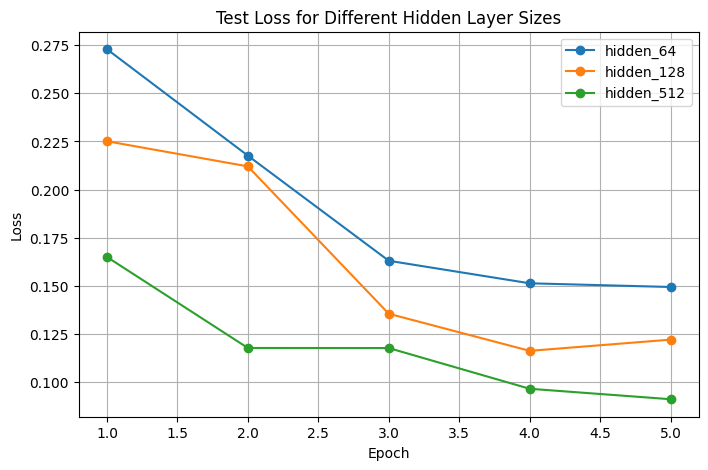

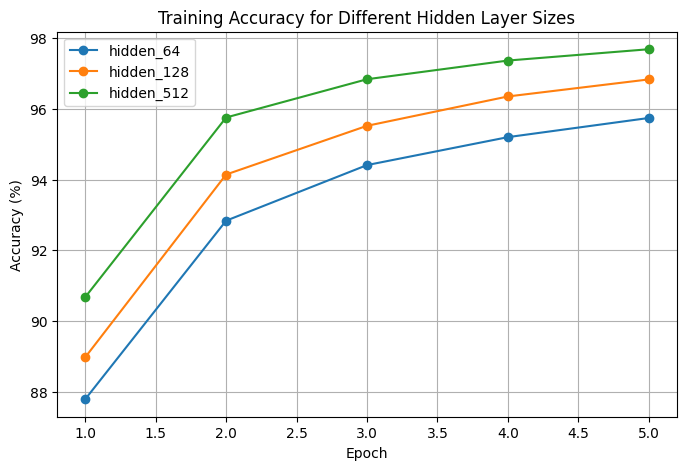

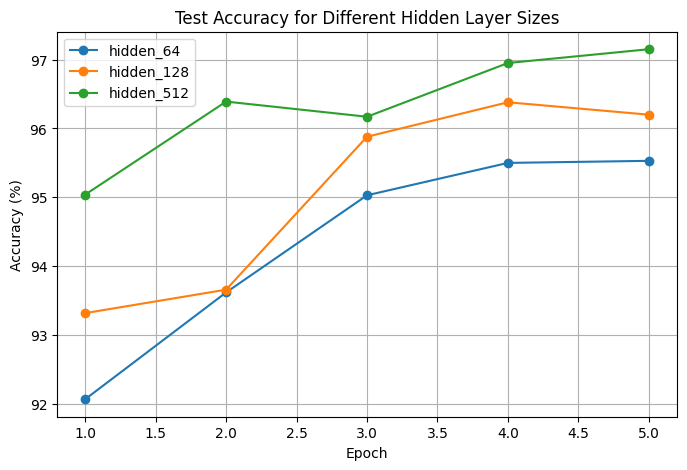

In [31]:
plot_metric(hidden_size_results, "train_losses", "Training Loss for Different Hidden Layer Sizes", "Loss")
plot_metric(hidden_size_results, "test_losses", "Test Loss for Different Hidden Layer Sizes", "Loss")
plot_metric(hidden_size_results, "train_accuracies", "Training Accuracy for Different Hidden Layer Sizes", "Accuracy (%)")
plot_metric(hidden_size_results, "test_accuracies", "Test Accuracy for Different Hidden Layer Sizes", "Accuracy (%)")

In [32]:
hidden_size_summary = summarise_results(hidden_size_results)
hidden_size_summary

,experiment,hidden_size,epochs,learning_rate,optimizer,final_train_loss,final_test_loss,final_train_accuracy,final_test_accuracy
0,hidden_512,512,5,0.001,adam,0.073798,0.091194,97.683333,97.15
1,hidden_128,128,5,0.001,adam,0.104326,0.122115,96.830000,96.20
2,hidden_64,64,5,0.001,adam,0.142620,0.149438,95.740000,95.53


Again, you can see how the smaller learning rate positively impacts test accuracy and loss, where the higher learning rates are learning 'too quickly', and fail to ake meaninful conections due to overfitting the training data.

This will continue for the rest of the hyperparameters to see the full effect of their variance.

In [33]:
optimizer_experiments = {
    "adam": {
        "hidden_size": 128,
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "adam"
    },
    "sgd": {
        "hidden_size": 128,
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "sgd"
    }
}

optimizer_results = run_experiment_group(optimizer_experiments, train_loader, test_loader)

Running experiment: adam
Config: {'hidden_size': 128, 'epochs': 5, 'learning_rate': 0.001, 'optimizer': 'adam'}
Epoch [1/5] | Train Loss: 0.3869 | Test Loss: 0.2397 | Train Acc: 88.73% | Test Acc: 92.92%
Epoch [2/5] | Train Loss: 0.2035 | Test Loss: 0.1712 | Train Acc: 94.04% | Test Acc: 94.67%
Epoch [3/5] | Train Loss: 0.1470 | Test Loss: 0.1385 | Train Acc: 95.68% | Test Acc: 95.86%
Epoch [4/5] | Train Loss: 0.1185 | Test Loss: 0.1146 | Train Acc: 96.45% | Test Acc: 96.45%
Epoch [5/5] | Train Loss: 0.1018 | Test Loss: 0.1059 | Train Acc: 96.88% | Test Acc: 96.74%
Running experiment: sgd
Config: {'hidden_size': 128, 'epochs': 5, 'learning_rate': 0.001, 'optimizer': 'sgd'}
Epoch [1/5] | Train Loss: 1.8961 | Test Loss: 1.4749 | Train Acc: 55.11% | Test Acc: 73.45%
Epoch [2/5] | Train Loss: 1.1776 | Test Loss: 0.9236 | Train Acc: 77.76% | Test Acc: 82.12%
Epoch [3/5] | Train Loss: 0.8080 | Test Loss: 0.6864 | Train Acc: 83.16% | Test Acc: 84.88%
Epoch [4/5] | Train Loss: 0.6425 | Test Lo

Optimisers

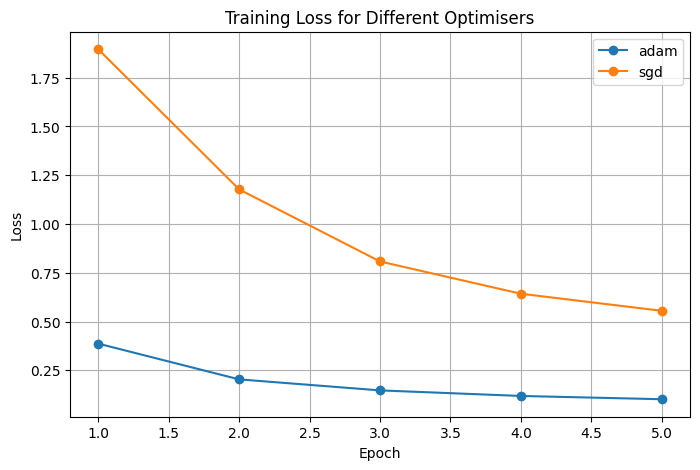

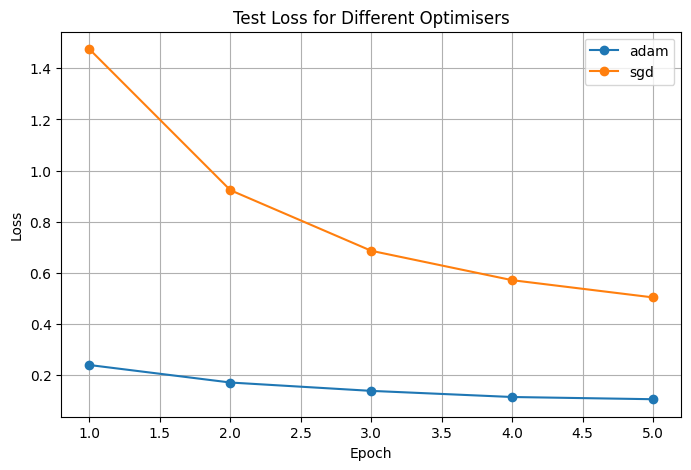

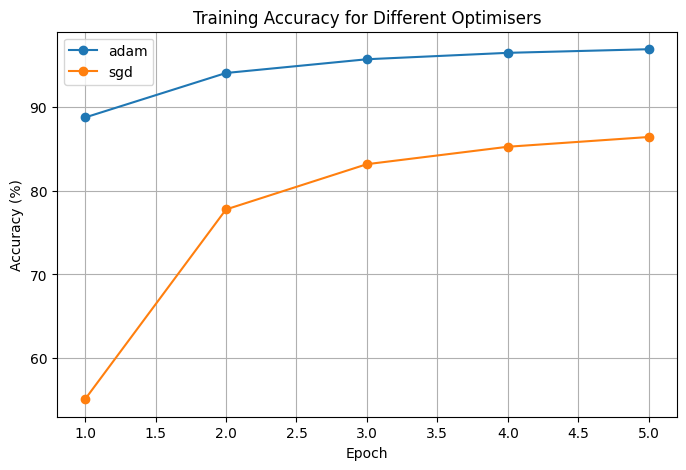

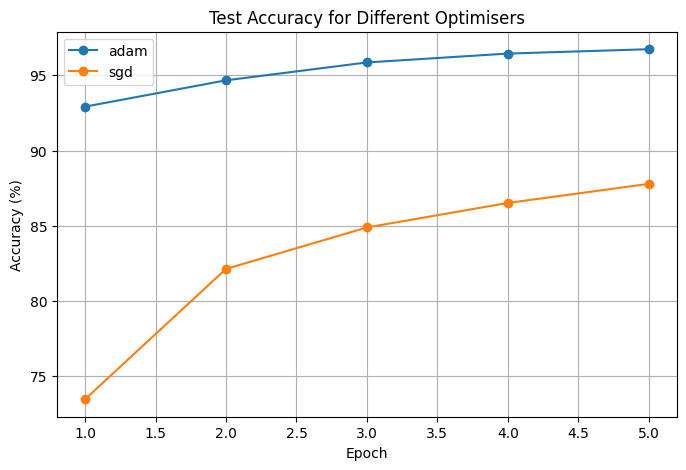

In [34]:
plot_metric(optimizer_results, "train_losses", "Training Loss for Different Optimisers", "Loss")
plot_metric(optimizer_results, "test_losses", "Test Loss for Different Optimisers", "Loss")
plot_metric(optimizer_results, "train_accuracies", "Training Accuracy for Different Optimisers", "Accuracy (%)")
plot_metric(optimizer_results, "test_accuracies", "Test Accuracy for Different Optimisers", "Accuracy (%)")

Plot the changes

In [35]:
optimizer_summary = summarise_results(optimizer_results)
optimizer_summary

,experiment,hidden_size,epochs,learning_rate,optimizer,final_train_loss,final_test_loss,final_train_accuracy,final_test_accuracy
0,adam,128,5,0.001,adam,0.101783,0.105918,96.878333,96.74
1,sgd,128,5,0.001,sgd,0.555019,0.504075,86.403333,87.78


as we can see , the most appropriate optimiser was adam reaching higher levels of accuracy and less loss than adam. 

##
Comparison to similar sources. 
---
---

The pytorch tutorial uses a deeper neural network, with more hidden layers and neurons. This can have an effect of increasing the time it takes to train the model. This example will be shown here. 

https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html

Define the model how it was defined in the tutorial

In [37]:
class TutorialNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)
    

#source 1: https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html

Then build the model 

In [ ]:
def build_model(config):
    model_type = config.get("model_type", "simple")

    if model_type == "simple":
        return SimpleNN(config["hidden_size"]).to(device)
    elif model_type == "tutorial":
        return TutorialNN().to(device)
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")
    
#source 1: https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html

Now train the model in a different light

In [ ]:
import time

def run_experiment(config, train_loader_used, test_loader_used):

    model = build_model(config)
    optimizer = build_optimizer(model, config)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    start_time = time.time()

    for epoch in range(config["epochs"]):
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader_used:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_train_loss / len(train_loader_used)
        train_accuracy = 100 * correct_train / total_train

        model.eval()
        running_test_loss = 0.0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for images, labels in test_loader_used:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        avg_test_loss = running_test_loss / len(test_loader_used)
        test_accuracy = 100 * correct_test / total_test

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        print(
            f"Epoch [{epoch+1}/{config['epochs']}] | "
            f"Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | Test Acc: {test_accuracy:.2f}%"
        )

    total_training_time = time.time() - start_time

    return {
        "config": copy.deepcopy(config),
        "model": model,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,
        "training_time_seconds": total_training_time
    }

Summarise the results 

In [40]:
def summarise_results(results):

    rows = []

    for name, result in results.items():
        rows.append({
            "experiment": name,
            "model_type": result["config"].get("model_type", "simple"),
            "hidden_size": result["config"].get("hidden_size", "N/A"),
            "epochs": result["config"]["epochs"],
            "learning_rate": result["config"]["learning_rate"],
            "optimizer": result["config"]["optimizer"],
            "final_train_loss": result["train_losses"][-1],
            "final_test_loss": result["test_losses"][-1],
            "final_train_accuracy": result["train_accuracies"][-1],
            "final_test_accuracy": result["test_accuracies"][-1],
            "training_time_seconds": result["training_time_seconds"]
        })

    return pd.DataFrame(rows).sort_values(by="final_test_accuracy", ascending=False).reset_index(drop=True)

We can allow for both models to be compared closely, both the source and my own 

In [41]:
comparison_experiments = {
    "my_model": {
        "model_type": "simple",
        "hidden_size": 128,
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "adam"
    },
    "tutorial_model": {
        "model_type": "tutorial",
        "epochs": 5,
        "learning_rate": 0.001,
        "optimizer": "adam"
    }
}

comparison_results = run_experiment_group(comparison_experiments, train_loader, test_loader)

Running experiment: my_model
Config: {'model_type': 'simple', 'hidden_size': 128, 'epochs': 5, 'learning_rate': 0.001, 'optimizer': 'adam'}
Epoch [1/5] | Train Loss: 0.3844 | Test Loss: 0.2169 | Train Acc: 88.78% | Test Acc: 93.44%
Epoch [2/5] | Train Loss: 0.2013 | Test Loss: 0.1612 | Train Acc: 94.12% | Test Acc: 95.04%
Epoch [3/5] | Train Loss: 0.1433 | Test Loss: 0.1310 | Train Acc: 95.74% | Test Acc: 96.08%
Epoch [4/5] | Train Loss: 0.1141 | Test Loss: 0.1051 | Train Acc: 96.64% | Test Acc: 97.06%
Epoch [5/5] | Train Loss: 0.0980 | Test Loss: 0.0995 | Train Acc: 96.97% | Test Acc: 97.14%
Running experiment: tutorial_model
Config: {'model_type': 'tutorial', 'epochs': 5, 'learning_rate': 0.001, 'optimizer': 'adam'}
Epoch [1/5] | Train Loss: 0.2845 | Test Loss: 0.1567 | Train Acc: 91.20% | Test Acc: 94.97%
Epoch [2/5] | Train Loss: 0.1358 | Test Loss: 0.1260 | Train Acc: 95.77% | Test Acc: 95.93%
Epoch [3/5] | Train Loss: 0.0999 | Test Loss: 0.0981 | Train Acc: 96.92% | Test Acc: 97.

Display the results

In [42]:
comparison_summary = summarise_results(comparison_results)
comparison_summary

,experiment,model_type,hidden_size,epochs,learning_rate,optimizer,final_train_loss,final_test_loss,final_train_accuracy,final_test_accuracy,training_time_seconds
0,my_model,simple,128,5,0.001,adam,0.098014,0.099523,96.965,97.14,124.424043
1,tutorial_model,tutorial,N/A,5,0.001,adam,0.069572,0.105674,97.860,96.64,130.205385


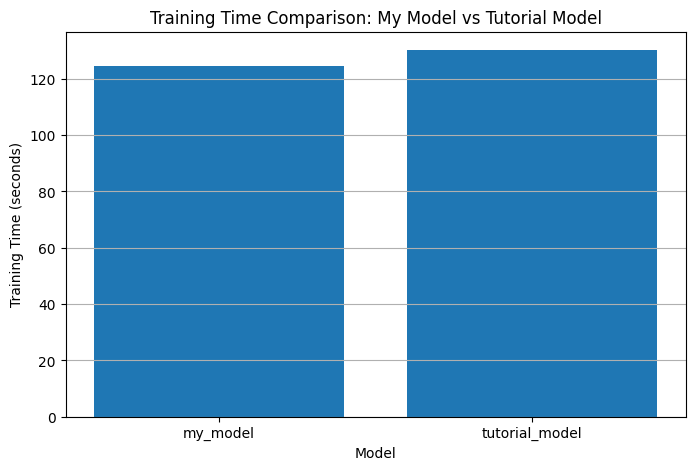

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_summary["experiment"], comparison_summary["training_time_seconds"])
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison: My Model vs Tutorial Model")
plt.grid(axis="y")
plt.show()

As you can see the training time has reduced , and as the number of elements becomes large this time difference can become significant, however fo the given task this is not so much so would be prefereable and an advantage to have a deeper model which can make more accurate connections within the neural netowrk. 

---
#
Summary

This is the end of the tutorial. We have 

Trained  multi-layered perceptron and evaluated the pipeline. 
Visually evaluated the use of different hyperparameters and seen their effects. 
Compared to similar solutions to see advantages and disadvantages.



#
References: https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html